In [344]:
import json, base64, re
import pickle as pkl

from typing import TypedDict, Dict, Any, List

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

from langchain.globals import set_debug, set_verbose
set_debug(False)
set_verbose(False)

In [345]:
def add_trace(state: dict, *, agent: str, role: str, payload):
    if "trace" not in state:
        state["trace"] = []
    state["trace"].append({
        "agent": agent,
        "role": role,
        "payload": payload,
    })
    
def extract_first_json(text: Any) -> Dict[str, Any]:
    """
    Extract the first JSON object from `text`.
    - Handles ```json fences.
    - Finds the first balanced {...} with brace counting.
    - Tries lightweight repairs (auto-closing braces).
    - Always returns a dict: parsed JSON or {"_raw": ..., "_reason": ...}.
    """
    # Fast paths for non-strings
    if isinstance(text, dict):
        return text
    if text is None:
        return {"_raw": "", "_reason": "none_input"}
    if not isinstance(text, str):
        return {"_raw": str(text), "_reason": f"not_a_string:{type(text).__name__}"}

    original = text
    s = text.strip()
    
    # Strip leading ``` or ```json fences and a trailing closing fence
    s = re.sub(r"^```[\w-]*\s*\n", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\n```[\s\t]*$", "", s)

    # 0) Whole-string JSON
    try:
        val = json.loads(s)
        return val if isinstance(val, dict) else {"_raw": s, "_reason": "json_root_not_object"}
    except Exception:
        pass

    # 1) Find first balanced { ... }
    start = s.find("{")
    if start == -1:
        return {"_raw": s, "_reason": "no_brace_found"}

    depth = 0
    in_string = False
    escape = False
    end = None

    for i, ch in enumerate(s[start:], start=start):
        if in_string:
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == '"':
                in_string = False
        else:
            if ch == '"':
                in_string = True
            elif ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    end = i
                    break

    candidate = s[start:(end + 1) if end is not None else len(s)]

    # 2) Parse balanced candidate
    if end is not None:
        try:
            val = json.loads(candidate)
            return val if isinstance(val, dict) else {"_raw": candidate, "_reason": "json_root_not_object"}
        except Exception as e:
            return {"_raw": candidate, "_reason": f"parse_error_balanced:{type(e).__name__}"}

    # 3) Try auto-closing braces (only if not inside a string)
    if not in_string and depth > 0:
        repaired = candidate + ("}" * depth)
        try:
            val = json.loads(repaired)
            return val if isinstance(val, dict) else {"_raw": repaired, "_reason": "json_root_not_object"}
        except Exception as e:
            return {"_raw": repaired, "_reason": f"parse_error_repaired:{type(e).__name__}"}

    # 4) Last resort
    return {"_raw": original, "_reason": "unbalanced_in_string_or_unknown"}

In [ ]:
observer_llm = ChatOpenAI(
    model="gpt-5-mini",
    temperature=0.0,
    use_responses_api=True
)

triage_llm = ChatOpenAI(
    model="gpt-5-mini",
    reasoning={"effort":"low"},
    max_completion_tokens=896,
    temperature=0.3,
    use_responses_api=True
)

specialist_llm = ChatOpenAI(
    model="gpt-5-mini",
    reasoning={"effort":"low"},
    max_completion_tokens=1300,
    temperature=0.7,
    use_responses_api=True
)

diagnose_llm = ChatOpenAI(
    model="gpt-5-mini",
    reasoning={"effort":"low"},
    temperature=0.7,
    max_completion_tokens=1300,
    use_responses_api=True
)

In [348]:
def invoke_llm(model, SYSTEM_PROMPT, user_message):
    messages =[
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=user_message)
    ]

    response = model.invoke(messages)
    return extract_first_json(response.text())


def encode_image(image_path):
    """Encode a local image to base64 string."""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')


## AGENT PROMPTS

In [349]:
OBSERVER_PROMPT ="""
Role: Dermatologist specializing in dermoscopy.

Task: Analyze the dermoscopic image and produce a complete, objective, structured JSON of all specified dermoscopic features, organized by visual category.

How to Think: Scan the image thoroughly by this order center → mid → periphery order, do not skip any features you seen.

STRICT RULES:
- Your output must be ONLY the JSON object specified in the schema. No prose.
- You must populate every single key in the schema. Do not omit any feature.
- Use enums only: state must be "present", "absent", or "unknown". 
- If you cannot determine the state of a feature, set state="unknown"

REUSABLE SUB-SCHEMA:
    FeatureField = { "state":"present|absent|unknown", detail": "Short details" }

JSON Schema:
{
  "global": {
    "symmetry": { "shape": "symmetric|asymmetric|unknown", "color": "symmetric|asymmetric|unknown" },
    "pattern": "reticular|globular|homogeneous|multicomponent|structureless|unknown"
  },
  "border": {
    "demarcation": "well|ill|partial|unknown",
    "shape": "regular|irregular|notched|fading|unknown"
  },
  "colors": {list of colors present},
    "structures": {
      "network": {
        "typical": FeatureField,
        "atypical": FeatureField,
        "pseudonetwork": FeatureField
      },
    "negative_network": FeatureField,
    "dots_globules": FeatureField,
    "streaks": FeatureField,
    "blotches": FeatureField,
    "veil": FeatureField,
    "regression": FeatureField,
    "shiny_white_lines": FeatureField,
    "leaf_structures": FeatureField,
    "spoke_wheels": FeatureField,
    "ovoid_nests": FeatureField,
    "milia_cysts": FeatureField,
    "comedo_openings": FeatureField,
    "cerebriform": FeatureField,
    "central_scar": FeatureField,
    "white_network": FeatureField,                
    "peripheral_delicate_network": FeatureField,  
    "peripheral_pigment_rim": FeatureField,
    "peripheral_network": FeatureField,
    "keratin_scale": FeatureField,
    "rosettes": FeatureField,
    "white_halos": FeatureField,
    "ulcer_crust": FeatureField
  },
  "vascular": {
    "arborizing": FeatureField,
    "glomerular": FeatureField,
    "polymorphous": FeatureField,
    "dotted": FeatureField,
    "linear": FeatureField,
    "lacunae": FeatureField,
    "red_patches": FeatureField,
    "dotted_in_lines": FeatureField 
  }
}
"""

TRIAGE_PROMPT = """
Role: Dermoscopy triage specialist.

Task: Given a structured description of a single lesion, you must follow a strict reasoning process to determine the most likely tumour family and output your findings in the specified JSON format. Your primary goal is to correctly handle potential "mimic" lesions by critically validating your initial findings.

How to reason:
Your task is to populate the fields in the required JSON schema. Follow these steps to determine the content for each field:
    1. For reasoning_steps.initial_finding: First, identify any Strong Anchors. Based on the most powerful anchor, state your initial hypothesis and the evidence for it.
    2. For reasoning_steps.cross_examination: You must now critically validate your initial finding.
        - supporting_evidence: Explicitly state whether other features from the same family support your initial hypothesis. List them or state "None."
        - contradictory_evidence: Explicitly state whether any features point to a different family. List them or state "None."
        - anchor_reliability: If supporting_evidence is "None" AND contradictory_evidence is "Yes," you must declare the anchor "Unreliable." In all other cases, declare it "Reliable." State the outcome and the reason.
        
    3. For final_conclusion:
        - If you judged the anchor to be Reliable in the previous step, state the final family probabilities with high confidence.
        - If you judged the anchor to be Unreliable, you must discard it. Base your final conclusion on the remaining evidence (usually the contradictory clues). The probabilities should reflect this high uncertainty, and the warning must explain that a mimic was suspected.
        - If no strong anchors were found initially, base the conclusion on the weak clues as per the original logic.

Feature Hierarchy
1. Strong Anchors (High Specificity)
  Melanocytic:
  - Pigment Network (typical or atypical, non-facial).
  - Negative Network.
  - Radial Streaming / Pseudopods (unambiguously at the lesion margin).
  - Peripheral Rim of regular, small Globules (mostly complete).

  Keratinocytic:
  - Milia-like Cysts or Comedo-like Openings.
  - Cerebriform Pattern / Fissures-and-Ridges.
  - Arborizing Vessels (must be thick, tapering, branching; not simple telangiectasia).
  - Blue-Gray Ovoid Nests.
  - Leaf-like / Spoke-wheel Structures.
  - Rosettes (four-dot clods, requires polarization).
  - Clustered or Linearly-Arranged Glomerular, Hairpin, or Dotted vessels.

Other_benign (Dermatofibroma):
  - Central White Scar-like Area / White Network combined with a Peripheral Delicate Pigmented Network.

2. Weak / Supportive Clues (Low Specificity - Use with Caution)
  General / Non-Specific (Do NOT use to confirm a specific family):
  - Asymmetry (shape or color).
  - Multicomponent pattern.
  - Multiple colors.
  - Disorganized dots or blotches.
  - Crucial Rule: These features increase suspicion for malignancy in general but do NOT help differentiate between a melanocytic and a keratinocytic cancer. They must NOT be used as 'supporting_evidence' for a specific family during cross-examination.

  Melanoma Modifiers (Only relevant if melanocytic strong anchors are present):
  - Blue-White Veil.
  - Regression Structures (peppering, scar-like areas).
  - Shiny White Structures (crystalline/chrysalis lines).
  - Polymorphous Vessels (multiple morphologies in one lesion).

  Keratinocytic Clues:
  - Sharp, "stuck-on" border.
  - Keratin Scale or Crust.
  - Ulceration (can also be in melanoma).
  - White Circles / Targetoid Follicular Openings.
  - Erythema (redness, either diffuse or in a strawberry pattern).
  - Isolated or non-clustered hairpin or dotted vessels.

  Other_benign (Dermatofibroma) Clues - for diagnosis of exclusion:
  - Symmetric, structureless pattern (especially if pink, red, or violaceous).
  - Yellowish-orange hue (suggests hemosiderin).
  - Absence of any strong melanocytic or keratinocytic anchors.

Notes:
1. Pseudonetwork vs. Network: A network-like pattern on a uniformly erythematous background, especially on the face, is a pseudonetwork (Keratinocytic clue), not a true pigment network.
2. DF Rim: The peripheral delicate network of a dermatofibroma is not a melanocytic network.
3. Streaks: Internal dark spikes within keratin or ulcer do not count as radial streaming. Streaks must be at the margin.
4. Final Check: A diagnosis should feel coherent. If you are relying on a single, poorly-formed weak clue to make a decision, confidence is low.


Return JSON Schema:
{
  "reasoning_steps": {
    "initial_finding": "Based on the [Strong Anchor], the initial hypothesis is [Family Name].",
    "cross_examination": {
      "supporting_evidence": "None.",
      "contradictory_evidence": "Yes, [Feature Name] is a clue for the [Family Name] family.",
      "anchor_reliability": "Unreliable, because the primary anchor is isolated and contradicted by other features."
    }
  },
  "final_conclusion": {
    "family_probs": {
      "melanocytic": 0.0,
      "keratinocytic": 0.0,
      "other_benign": 0.0
    },
    "key_features": ["short phrases of decisive findings"],
    "warnings": ["reasons/conflicts confidence is limited"]
  }
}
"""

MELANOCYTIC_SPECIALIST_PROMPT = """
Role: You are a dermoscopy specialist with deep expertise in melanocytic lesions.

Scope & labels:
Classify a single lesion as: nevus, melanoma. If evidence is insufficient, you may return "uncertain".

Input: Image Features.

Protocol: The shared features are common, it SHOULD NOT outweigh Dermoscopic specific features.

How to reason:
1. ABCDE scan:
  - A (Asymmetry): One half of the mole does not match the other half in shape or color.
  - B (Border): irregular/notched/abrupt, the edges are ragged, notched, blurred, or uneven.
  - C (Color): multiple colors, not uniform. Shades of tan, brown, black, red, white, or blue may be present.
  - D (Diameter): >6 mm is supportive, not decisive.
  - E (Evolving): The mole is changing in size, shape, color, or elevation.
  *ABCDE cues are context; C (white/gray/blue/black) and A are most useful. D/E are supportive only.

2. Dermoscopic specific features:
  - Both shared: asymmetry/chaos, multicomponent look, dots/globules, blotches, broad colour range, generic tructureless.
  - Melanoma clues: streaks/pseudopods; atypical pigment network or negative network; blue-white veil with melanocytic lines; shiny white structures; regression (peppering or white scar); linear-irregular / polymorphous vessels; ulcer/bleeding; broad central/eccentric black/blue/gray structureless area.
  - Nevus clues: typical network; orderly peripheral rim of small, regular globules (mostly complete); coherent homogeneous/regular reticular or globular architecture.

Notes:
- Only consider melanoma if you see a melanocytic line.
- Do not call melanoma from veil/regression/shiny whites/polymorphous vessels.

Output (JSON only)
{
  "top_label": "nevus | melanoma | uncertain",
  "confidence": 0.0-1.0,
  "class_probs": { "nevus": 0.0, "melanoma": 0.0 },
  "evidence": {
    "nevus":    { "key_present": [], "key_absent": [], "notes": [] },
    "melanoma": { "key_present": [], "key_absent": [], "notes": [] }
  },
  "warnings": ["optional"]
}
"""

KERATINOCYTIC_SPECIALIST_PROMPT = """
Role: You are a dermoscopy specialist with deep expertise in keratinocytic lesions.

Task & labels:
Classify a single lesion among: pbk (pigmented benign keratosis), bcc (basal cell carcinoma), scc (squamous cell carcinoma), ak (actinic keratosis). If evidence is insufficient, you may return "uncertain".

Input: Image Features.

Ground Rules (Truth Handling):
  - Treat 'present/absent' as ground truth. Do not invent or relabel features.
  - Distinguish scale from keratin: "Fine, patchy, or superficial scale" ≠ "Keratin mass/crust/horn".
  - "Pink" background color ≠ "Erythema"; only call erythema when explicit (e.g., red patches).
  - Arborizing vessels must have a thick intralesional trunk with convincing branching and taper. Fine serpentine lines or scattered telangiectasia are NOT arborizing.
  
Step 1: Identify Disease Anchors & Suggestors
First, evaluate the input features to determine which anchors and suggestors are present for each disease.

  Primary Disease Anchors (Decisive):
    - PBK: milia-like cysts; comedo-like openings; cerebriform/fingerprint surface; sharp or moth-eaten edge.
    - BCC: arborizing vessels (meeting the strict definition); blue-gray ovoid nests; leaf-like areas; spoke-wheels.
    - SCC (Core Cluster): Requires both A and B:
      - A: (ulcer/erosion OR keratin mass/marked scale OR extensive white structureless areas)
      - B: (clustered hairpin/glomerular/dotted vessels, often with white halos)
    - AK: strawberry pseudonetwork (erythema with follicular openings); white circles/targetoid follicles; rosettes; clustered keratin-type vessels clearly arranged around follicles.

  Suggestive Cues (For use when no decisive anchors are present):
    - AK: diffuse erythema; dotted vessels (not clustered); thin/patchy scale; ill-defined pink plaque.
    - SCC: yellow-orange keratin-like hue; non-clustered keratin-type vessels (hairpin/glomerular); focal crust/erosion; focal/minor white structureless areas.
    - BCC: fine telangiectasia/serpentine lines (non-arborizing); shiny white lines; slight translucency.
    - PBK: (This category has no "soft" suggestors; its features are considered decisive anchors).

Step 2: Apply the Diagnostic Flow (Deterministic)
Follow these rules in strict order. The first rule that is fully met determines the top_label.

  1. Check for SCC/BCC Collision: If a BCC Anchor is present AND an SCC Core Cluster is present:
   - Label as scc if the features of the SCC cluster (ulcer, keratin, white areas) cover more than 50% of the lesion.
   - Otherwise, label as bcc.

  2. Check for Standalone SCC: If an SCC Core Cluster is present (and Rule #1 does not apply), label as scc.
  3. Check for Standalone BCC: If a BCC Anchor is present (and Rule #1 does not apply), label as bcc.
  4. Check for Standalone AK: If an AK Anchor is present (and no BCC or SCC anchors are present), label as ak.
  5. Check for Standalone PBK: If one or more PBK Anchors are present (and no BCC, SCC, or AK anchors are present), label as pbk.
  6. Evaluate by Suggestive Cues (if no anchors were found):
    Define Cue Specificity: High > Medium > Low.
      - High: shiny white lines (BCC); yellow-orange keratin hue (SCC).
      - Medium: fine telangiectasia (BCC); non-clustered hairpin/glomerular vessels (SCC); white circles (AK).
      - Low: diffuse erythema (AK); thin scale (AK); ill-defined border (AK).

    Apply Logic:
      - If cues for only one disease are present, choose that disease.
      - If cues for multiple diseases are present, choose the disease with the highest specificity cue.
      - If there's a tie in specificity (e.g., both High), prefer scc over bcc, and bcc over ak.
      - Special Case: For a lesion described only as a diffuse erythematous plaque with low-specificity AK cues (erythema, scale) and no keratin/ulcer, prefer ak over scc.

  7. Final Default: If no anchors or suggestive cues are present at all, label as uncertain.

Output (JSON only)
{
  "top_label": "pbk | bcc | scc | ak | uncertain",
  "confidence": 0.0-1.0,
  "class_probs": { "pbk": 0.0, "bcc": 0.0, "scc": 0.0, "ak": 0.0 },
  "evidence": {
    "pbk": { "key_present": [], "key_absent": [], "notes": [] },
    "bcc": { "key_present": [], "key_absent": [], "notes": [] },
    "scc": { "key_present": [], "key_absent": [], "notes": [] },
    "ak":  { "key_present": [], "key_absent": [], "notes": [] }
  },
  "warnings": ["optional reasons certainty is limited or features conflict"]
}

Constraints
- Output JSON only.
- List only evidence derivable from input; do not infer unprovided findings.
"""

DIAGNOSE_PROMPT = """
Role: You are a dermatology diagnostician who synthesizes dermoscopic specialist outputs.

Scope & labels:
Choose one primary label and provide a ranked differential across these 7 labels:
nevus, melanoma, basal cell carcinoma (bcc), squamous cell carcinoma (scc), pigment benign keratosis (pbk), actinic keratosis (ak), dermatofibroma (df).

Inputs:
- image_features_json
- triage_json: family-level triage (no subtype) with confidence and key_features.
- specialist_json (optional): one or more specialist results, each with class_probs, evidence, warnings.

How to reason:
- Use anchors only from inputs; unknown ≠ absent; no invention.
- Centrality: count pigment/negative network, streaks, or rim of regular globules as melanocytic ONLY if they organize the centre or span ≥2 sectors. Peripheral/faint “network-like” ≠ melanocytic context.
- Keratin-malignancy override: if the tumour core shows ≥2 of {ulcer/erosion, keratin scale/mass, keratin-type vessels (dotted/hairpin/glomerular; clustered or focal), broad white structureless areas} AND melanocytic lines don't dominate centrally → prefer SCC.
- Ambiguous “milia-like cysts” in white areas: treat as white circles/targetoid follicles ONLY when follicular openings/facial site are documented; otherwise devalue as PBK evidence.
- Prefer central, image-verified anchors over peripheral/text-only claims. If triage vs specialist disagree, pick the side with stronger central anchors and explain in warnings.
- Shared cues (never decisive): asymmetry/chaos, multicomponent, dots/globules, blotches/structureless brown, wide colour range, diffuse erythema/thin scale.

Anchor cheat-sheet:
- Melanocytic context: central/sector-spanning network or negative network, streaks/pseudopods, or orderly rim of small regular globules (then veil/regression/shiny whites/polymorphous vessels can upweight melanoma).
- BCC: arborizing vessels; blue-gray ovoid nests; leaf-like; spoke-wheel.
- AK: strawberry/pseudonetwork (erythema with follicular openings); white circles/targetoid follicles; rosettes; clustered keratin-type vessels.
- SCC: keratin-malignancy cluster (see override rule).
- DF: central DF white (scar-like white / central white network / central shiny white lines) + peripheral delicate rim; no BCC hallmarks.

Output JSON only (no extra prose)
{
  "diagnosis": "<Label>",
  "confidence": 0.0-1.0,
  "differential": [<up to two other possible diagnoses with reason "why?">],
  "support": ["bullet list of the key decisive findings actually present"],
  "warning": ["optional: conflicts, unknowns, red flags reducing certainty"],
  "recommendation": "<Recommendation for next step>"
}

Constraints
- Valid JSON only; include only the keys above.
- Base conclusions solely on provided evidence; do not invent findings. Unknown ≠ absent.
- “recommendation” is non-directive and for informational use—not medical advice.
"""

## AGENT NODES

In [351]:
class DermState(TypedDict):
    user_prompt: str
    image_path: str
    image_features: Dict[str, Any]
    triage_result: Dict[str, Any]
    specialist_queue: List[str]
    specialist_results: List[Dict[str, Any]]
    diagnose_result: Dict[str, Any]
    trace: List[Dict[str, Any]]
    
def feature_extraction(state: DermState):
    image_path = state.get("image_path", "")
    image_data = encode_image(image_path)
    
    user_message = [{
            "type": "image_url",
            "image_url": { "url": f"data:image/jpeg;base64,{image_data}" }
        }]
    
    try:
        img_features = invoke_llm(observer_llm, OBSERVER_PROMPT, user_message)  
        add_trace(state, agent="observer", role="user", payload=img_features)

    except Exception as e:
        print(f"Error occurred during feature extraction: {e}")
    
    return {
        "image_features": img_features
    }
    
def triage_node(state: DermState):
    image_features = state.get("image_features", {})
    
    user_message = [
        {
            "type": "text",
            "text": f"Image Features:\n{json.dumps(image_features, ensure_ascii=False)}"
        }
    ]

    
    # triage_result = invoke_llm(triage_llm, TRIAGE_PROMPT, user_message)
    triage_result = invoke_llm(triage_llm, TRIAGE_PROMPT, user_message)
    add_trace(state, agent="triage", role="user", payload=triage_result)

    return {
        "triage_result": triage_result
    }

def plan_specialists(state: DermState):
    triage = state.get("triage_result", {})
    probs = (triage.get("family_probs") or {})
    queue: list[str] = []

    # threshold you asked for: run any family >= 0.20
    if probs.get("melanocytic", 0) >= 0.20:
        queue.append("melanocytic_specialist")
    if probs.get("keratinocytic", 0) >= 0.20:
        queue.append("keratinocytic_specialist")

    return {"specialist_queue": queue}

def next_specialist_router(state: DermState):
    queue: list[str] = state.get("specialist_queue", []) or []
    if not queue:
        return "diagnosis"
    return queue[0]  # head-of-queue: either "melanocytic_specialist" or "keratinocytic_specialist"

def melanocytic_specialist(state: DermState):
    image_features = state.get("image_features", {})
    spec_list = state.get("specialist_results", []) or []

    user_message = [{"type": "text", "text": f"Image Features:\n{json.dumps(image_features, ensure_ascii=False)}"}]
    result = invoke_llm(specialist_llm, MELANOCYTIC_SPECIALIST_PROMPT, user_message)

    spec_list.append(result)
    add_trace(state, agent="melanocytic_specialist", role="user", payload=result)

    # pop head if it's me
    q = state.get("specialist_queue", []) or []
    if q and q[0] == "melanocytic_specialist":
        q = q[1:]
    return {"specialist_results": spec_list, "specialist_queue": q}

def keratinocytic_specialist(state: DermState):
    image_features = state.get("image_features", {})
    spec_list = state.get("specialist_results", []) or []

    user_message = [{"type": "text", "text": f"Image Features:\n{json.dumps(image_features, ensure_ascii=False)}"}]
    result = invoke_llm(specialist_llm, KERATINOCYTIC_SPECIALIST_PROMPT, user_message)

    spec_list.append(result)
    add_trace(state, agent="keratinocytic_specialist", role="user", payload=result)

    # pop head if it's me
    q = state.get("specialist_queue", []) or []
    if q and q[0] == "keratinocytic_specialist":
        q = q[1:]
    return {"specialist_results": spec_list, "specialist_queue": q}

def diagnosis_node(state: DermState):
    image_features = state.get("image_features", {})
    triage_result = state.get("triage_result", {})
    spec_results = state.get("specialist_results", [])
    if not isinstance(spec_results, list): spec_results = []
    
    user_message = [
        {
            "type": "text",
            "text": f"Image Features:\n{json.dumps(image_features, ensure_ascii=False)}\nTriage Result:\n{json.dumps(triage_result, ensure_ascii=False)}"
        }
    ]

    if spec_results:
        user_message.append({
            "type": "text",
            "text": f"\nSpecialist Results:\n{json.dumps(spec_results, ensure_ascii=False)}"
        })

    diagnosis_result = invoke_llm(diagnose_llm, DIAGNOSE_PROMPT, user_message)

    add_trace(state, agent="diagnosis", role="user", payload=diagnosis_result)

    return {
        "diagnosis_result": diagnosis_result
    }

## LangGraph Flow

In [352]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver

workflow = StateGraph(DermState)

# existing nodes
workflow.add_node("feature_extraction", feature_extraction)
workflow.add_node("triage", triage_node)
workflow.add_node("melanocytic_specialist", melanocytic_specialist)
workflow.add_node("keratinocytic_specialist", keratinocytic_specialist)
workflow.add_node("diagnosis", diagnosis_node)

# NEW nodes
workflow.add_node("plan_specialists", plan_specialists)
workflow.add_node("route_next_specialist", lambda s: s)  # no-op node; routing handled by conditional

workflow.set_entry_point("feature_extraction")

workflow.add_edge("feature_extraction", "triage")

# after triage, build the queue
workflow.add_edge("triage", "plan_specialists")

# from the planner, route to first specialist (or diagnosis if none)
workflow.add_conditional_edges(
    "plan_specialists",
    next_specialist_router,
    {
        "melanocytic_specialist": "melanocytic_specialist",
        "keratinocytic_specialist": "keratinocytic_specialist",
        "diagnosis": "diagnosis",
    }
)

# after each specialist, loop back to router for the next one (if any)
workflow.add_conditional_edges(
    "melanocytic_specialist",
    next_specialist_router,
    {
        "keratinocytic_specialist": "keratinocytic_specialist",
        "diagnosis": "diagnosis",
    }
)

workflow.add_conditional_edges(
    "keratinocytic_specialist",
    next_specialist_router,
    {
        "melanocytic_specialist": "melanocytic_specialist",
        "diagnosis": "diagnosis",
    }
)

workflow.add_edge("diagnosis", END)

checkpointer = InMemorySaver()

app = workflow.compile(checkpointer=checkpointer)

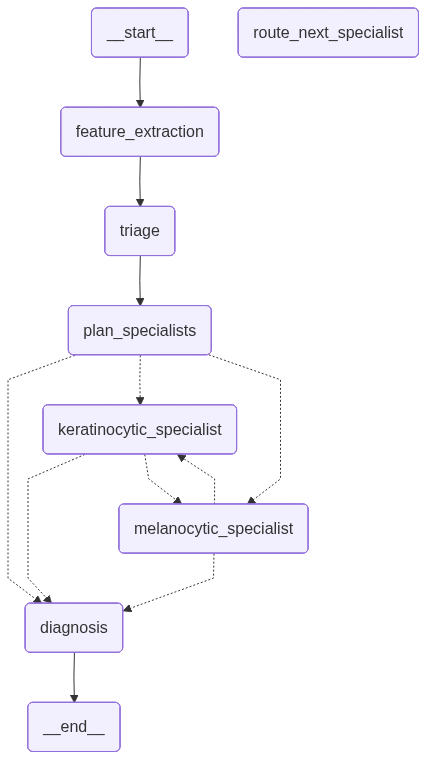

In [353]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## INFERENCE

In [360]:
from tqdm import tqdm
from pathlib import Path
import time

def run_evaluation_in_batch(
    app,
    test_dataset: List[Dict[str, Any]],
    out_dir: str,
    *,
    resume: bool = True,
    log_interval: int = 10,
) -> Path:
    """
    Runs the agent over a list of items shaped like:
        {"img_path": "...", "diagnosis": "...", "melanocytic": Optional[bool]}
    and writes the *final agent state* for each item as one JSON line to:
        <out_dir>/agent_evaluation_full.jsonl

    - No timeout.
    - Resume-safe: skips items already present in the JSONL (by image stem).
    - Returns the Path to the JSONL file.
    """
    print("🚀 Starting evaluation (JSONL only)…")
    print(f"📊 Dataset size: {len(test_dataset)}")
    print(f"🔄 Resuming: {resume}")

    out_dir_p = Path(out_dir)
    out_dir_p.mkdir(parents=True, exist_ok=True)
    jsonl_path = out_dir_p / "agent_evaluation_full_v2.jsonl"

    processed_ids = set()
    if resume and jsonl_path.exists():
        print(f"🔁 Resuming from {jsonl_path}")
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    st = json.loads(line)
                    # Accept either 'image_path' or 'image_path' for robustness
                    p = st.get("image_path") or st.get("image_path") or ""
                    if p:
                        processed_ids.add(Path(p).stem)
                except Exception:
                    # ignore malformed lines during resume scan
                    pass
        print(f"✅ Already processed: {len(processed_ids)} images")

    # Filter items to process
    unprocessed = [it for it in test_dataset if Path(it["image_path"]).stem not in processed_ids]
    total = len(test_dataset)
    remaining = len(unprocessed)
    print(f"⏭️  To process: {remaining}/{total}")

    # Open JSONL file for append or write fresh
    mode = "a" if resume and jsonl_path.exists() else "w"
    n_ok, n_fail = 0, 0

    with open(jsonl_path, mode, encoding="utf-8") as jf:
        if remaining > 0:
            iterator = tqdm(unprocessed, desc="Processing Images", unit="img")
            start_time = time.time()

            for i, item in enumerate(iterator):
                image_stem = Path(item["image_path"]).stem
                try:
                    # Minimal initial state your app expects
                    state = {
                        "image_path": item["image_path"],
                        "ground_truth": item.get("diagnosis") or item.get("label") or "",
                        "melanocytic_gt": item.get("melanocytic", ""),
                        "trace": [],
                    }
                    config = {"configurable": {"thread_id": f"case-{image_stem}"}}

                    final_state = app.invoke(state, config=config)

                    # Ensure resume keys are present in the saved line
                    if "image_path" not in final_state:
                        final_state["image_path"] = item["image_path"]
                    if "ground_truth" not in final_state:
                        final_state["ground_truth"] = state["ground_truth"]
                    if "melanocytic_gt" not in final_state and "melanocytic" in item:
                        final_state["melanocytic_gt"] = item.get("melanocytic", "")

                    jf.write(json.dumps(final_state, ensure_ascii=False) + "\n")
                    jf.flush()
                    n_ok += 1

                    # Progress / ETA
                    if (i + 1) % log_interval == 0:
                        elapsed = time.time() - start_time
                        avg = elapsed / (i + 1)
                        eta = avg * (remaining - i - 1)
                        print(f"⏳ Progress: {i+1}/{remaining} | ETA: {int(eta//60)}m {int(eta%60)}s")

                except Exception as e:
                    err = f"{type(e).__name__}: {str(e)}"
                    print(f"❌ Failed on {image_stem}: {err}")
                    error_state = {
                        "image_path": item["image_path"],
                        "ground_truth": item.get("diagnosis") or item.get("label") or "",
                        "melanocytic_gt": item.get("melanocytic", ""),
                        "_error": err,
                        "trace": [],
                    }
                    jf.write(json.dumps(error_state, ensure_ascii=False) + "\n")
                    jf.flush()
                    n_fail += 1

    # Summary
    print("\n" + "="*48)
    print("✅ EVALUATION COMPLETE (JSONL only)")
    print(f"   Total items: {total}")
    print(f"   Newly processed: {n_ok}")
    print(f"   Newly failed:    {n_fail}")
    print(f"   JSONL saved to:  {jsonl_path}")
    print("="*48)

    return jsonl_path

In [361]:
with open("../dataset/300_test_set.pkl", "rb") as f:
    test_set = pkl.load(f)

In [362]:
image_path = "../dataset/test"
for item in test_set:
    file_name = Path(item["image_path"]).name
    item["image_path"] = f"{image_path}/{file_name}"

In [363]:
test_set[:1]

[{'image_path': '../dataset/test/ISIC_0025686.jpg',
  'age': '65.0',
  'sex': 'male',
  'anatom_site': 'unknown',
  'diagnosis': 'Nevus',
  'melanocytic': True}]

In [364]:
import os

has_images = []
test_images_count = 0

for image in os.listdir("../dataset/test"):
    if image.endswith('.jpg'):
        test_images_count += 1
        image_id = os.path.splitext(image)[0]
        
        # Check if this image id exists in the test metadata
        if image_id in [Path(item["image_path"]).stem for item in test_set]:
            has_images.append(image_id)
            
if has_images:
    print(f"Found {len(has_images)} test images")
    print(f"First few image IDs: {has_images[:5]}")


Found 300 test images
First few image IDs: ['ISIC_0034357', 'ISIC_0032040', 'ISIC_0035713', 'ISIC_0031993', 'ISIC_0024408']


In [367]:
OUTPUT_DIR = "../results"

jsonl_file = run_evaluation_in_batch(app, test_set, out_dir=OUTPUT_DIR, resume=True)
print("JSONL at:", jsonl_file)

🚀 Starting evaluation (JSONL only)…
📊 Dataset size: 300
🔄 Resuming: True
🔁 Resuming from ../results/agent_evaluation_full_v2.jsonl
✅ Already processed: 0 images
⏭️  To process: 300/300


Processing Images:   3%|▎         | 10/300 [09:23<4:27:57, 55.44s/img]

⏳ Progress: 10/300 | ETA: 272m 31s


Processing Images:   7%|▋         | 20/300 [18:26<3:56:51, 50.76s/img]

⏳ Progress: 20/300 | ETA: 258m 13s


...

⏳ Progress: 280/300 | ETA: 19m 30s


Processing Images:  97%|█████████▋| 290/300 [4:44:06<10:20, 62.00s/img]

⏳ Progress: 290/300 | ETA: 9m 47s


Processing Images: 100%|██████████| 300/300 [4:53:51<00:00, 58.77s/img]

⏳ Progress: 300/300 | ETA: 0m 0s

✅ EVALUATION COMPLETE (JSONL only)
   Total items: 300
   Newly processed: 300
   Newly failed:    0
   JSONL saved to:  ../results/agent_evaluation_full_v2.jsonl
JSONL at: ../results/agent_evaluation_full_v2.jsonl


In [336]:
# DF label
initial_state = {
    "image_path": "../dataset/small_test/ISIC_0029578.jpg",
    "trace": []
}

response = feature_extraction(initial_state)

print(type(response))
print(response)

<class 'dict'>
{'image_features': {'global': {'symmetry': {'shape': 'asymmetric', 'color': 'asymmetric'}, 'pattern': 'multicomponent'}, 'border': {'demarcation': 'ill', 'shape': 'irregular'}, 'colors': {'black': {'state': 'present', 'confidence': 'med'}, 'dark_brown': {'state': 'present', 'confidence': 'high'}, 'light_brown': {'state': 'present', 'confidence': 'high'}, 'tan': {'state': 'present', 'confidence': 'med'}, 'blue_gray': {'state': 'present', 'confidence': 'med'}, 'white': {'state': 'present', 'confidence': 'med'}, 'red': {'state': 'absent', 'confidence': 'high'}, 'pink': {'state': 'absent', 'confidence': 'high'}, 'yellow': {'state': 'absent', 'confidence': 'high'}, 'gray': {'state': 'present', 'confidence': 'med'}}, 'structures': {'network': {'state': 'absent', 'confidence': 'high'}, 'negative_network': {'state': 'absent', 'confidence': 'high'}, 'dots_globules': {'state': 'present', 'confidence': 'high'}, 'streaks': {'state': 'absent', 'confidence': 'high'}, 'blotches': {'sta

In [343]:
state = {
    "image_features": response
}

triage_res = triage_node(state)

print(type(triage_res))
print(triage_res)

<class 'dict'>
{'triage_result': {'family_probs': {'melanocytic': 0.85, 'keratinocytic': 0.1, 'other_benign': 0.05}, 'key_features': ['Asymmetric multicomponent pattern', 'Black and dark brown pigmentation with irregular blotches', 'Aggregated dots/globules (high confidence)', 'Blue-gray veil and gray (suggests regression/dermal pigment)', 'Regression structures present', 'Keratin/scale and occasional milia-like cysts (minor keratinocytic features)'], 'warnings': ['Strong melanocytic/melanoma anchors (blue-white veil, irregular dots/blotches, regression) favor melanocytic family, but presence of milia-like cysts and surface scale are keratinocytic clues — possible collision or secondary change.', 'No BCC-specific vascular or ovoid nest features identified.', 'Asymmetric, multicolour lesion with veil/regression warrants prompt dermatologic evaluation and likely excisional biopsy for histopathology.']}}


In [199]:
state = {
    "triage_result": triage_res
}

router_control(state)

'keratinocytic_specialist'

In [129]:
state = {
    "image_features": response
}

k_res = keratinocytic_specialist(state)
print(type(k_res))
print(k_res)

<class 'dict'>
{'specialist_results': ['{\n  "top_label": "scc",\n  "confidence": 0.70,\n  "class_probs": {\n    "pbk": 0.15,\n    "bcc": 0.05,\n    "scc": 0.70,\n    "ak": 0.10\n  },\n  "evidence": {\n    "pbk": {\n      "key_present": [\n        "brown blotches (present)"\n      ],\n      "key_absent": [\n        "sharply demarcated edge (demarcation is partial)",\n        "comedo-like openings (absent)",\n        "cerebriform/fingerprint surface (cerebriform absent)"\n      ],\n      "notes": [\n        "Some pigmented blotches can occur in PBK, but the lesion lacks classic PBK structures (milia cysts unknown, comedo openings absent) and is asymmetric/irregular which argues against typical benign keratosis."\n      ]\n    },\n    "bcc": {\n      "key_present": [],\n      "key_absent": [\n        "arborizing vessels (absent)",\n        "blue-gray ovoid nests (ovoid_nests absent)",\n        "leaf-like or spoke-wheel structures (leaf_structures and spoke_wheels absent)"\n      ],\n    

In [133]:
state = {
    "image_features": response,
    "triage_results": triage_res,
    "specialist_results": [k_res]
}

diag = diagnosis_node(state)
print(diag)

{'diagnosis_result': '{\n  "diagnosis": "squamous cell carcinoma",\n  "confidence": 0.8,\n  "differential": [\n    {\n      "diagnosis": "pigmented benign keratosis",\n      "reason": "presence of brown blotches and pigment could reflect PBK, but lack of classic keratosis structures (comedo-like openings, cerebriform surface unknown/missing) and lesion asymmetry/ulceration argue against PBK as primary."\n    },\n    {\n      "diagnosis": "actinic keratosis",\n      "reason": "scale and pink/red coloration are compatible with AK, however the presence of ulcer/crust, irregular asymmetric architecture and prominent pigmented blotches make SCC more likely."\n    }\n  ],\n  "support": [\n    "keratin scale present (medium confidence)",\n    "ulcer/crust present (medium confidence)",\n    "red/pink coloration and red patches present (medium confidence)",\n    "linear and dotted vessels present (medium confidence)",\n    "asymmetric shape and color with irregular/partially demarcated border",